# Lab 7 — Decision Trees and Random Forests

## Decision Trees

A Decision Tree is a **rule-based** model that learns a sequence of yes/no questions about features to make predictions. It's one of the most intuitive algorithms in machine learning because the final model can be drawn as a literal flowchart and explained to anyone.

At each step the algorithm asks: *"What single question, if answered, reduces my uncertainty the most?"* It repeats this process recursively until it reaches a decision.

* **For Classification:** Each leaf node outputs the majority class of the training samples that landed there.
* **For Regression:** Each leaf node outputs the mean of the training samples that landed there.

### The Key Concept: Impurity
The algorithm measures how "mixed" the samples at a node are using an **impurity metric**:
* **Gini Impurity** (default in scikit-learn): Probability of misclassifying a randomly chosen sample. Gini = 0 means a perfectly pure node (all one class).
* **Entropy / Information Gain**: Measures disorder using information theory. Produces similar splits to Gini in practice.

### The Golden Rule: Trees Don't Need Scaling!
Unlike KNN, both Decision Trees and Random Forests make decisions by comparing **thresholds** on individual features, not by measuring distances. Scaling makes no difference to the result. You can skip `StandardScaler` entirely.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## 1. Decision Tree Classification (Heart Disease Dataset)

We will use the **Heart Disease** dataset to predict whether a patient has heart disease. It contains 13 clinical features (age, cholesterol, chest pain type, etc.) and a binary target: `1` = disease present, `0` = absent.

This dataset is ideal for a Decision Tree because the features are a natural mix of numeric and categorical-like values, and the rules the tree learns (e.g., *"if chest pain type = typical angina AND max heart rate < 120 → disease likely"*) are clinically interpretable.

In [2]:
# Load the Heart Disease dataset from the UCI repository via sklearn
from sklearn.datasets import fetch_openml

try:
    df = pd.read_csv('heart.csv')
    print("Loaded from CSV.")
except FileNotFoundError:
    heart = fetch_openml('heart-statlog', version=1, as_frame=True, parser='auto')
    df = heart.frame.copy()
    df['class'] = (df['class'] == 'present').astype(int)
    df.rename(columns={'class': 'target'}, inplace=True)
    # Ensure all columns are numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)
    print("Loaded from OpenML.")

print(f"Dataset shape: {df.shape}")
df.head()

Loaded from OpenML.
Dataset shape: (270, 14)


,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [3]:
# Quick check — class balance and missing values
print("Target distribution:")
print(df['target'].value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")

Target distribution:
target
0    150
1    120
Name: count, dtype: int64

Missing values: 0


Text(0, 0.5, 'Count')

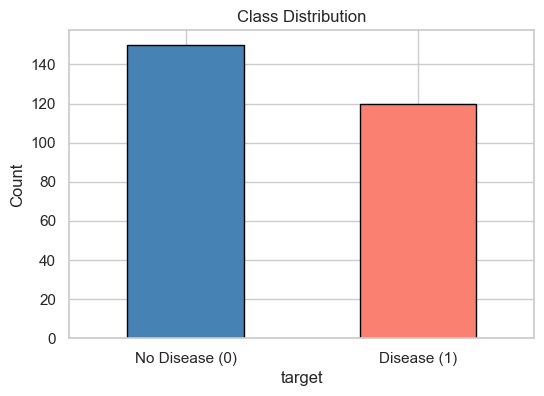

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'],
                                  edgecolor='black', width=0.5)
ax.set_title('Class Distribution', fontsize=12)
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
ax.set_ylabel('Count')

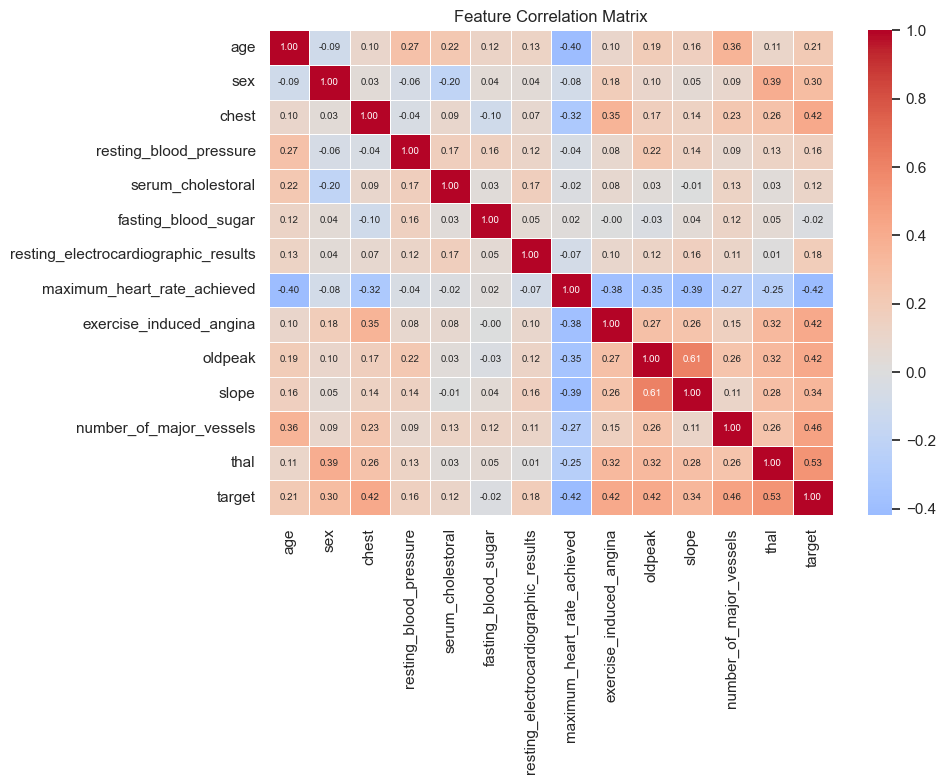

In [5]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
# Split — no scaling needed for trees!
X = df.drop('target', axis=1)
y = df['target']
feature_names = X.columns.tolist()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

Training set : 216 samples
Test set     : 54 samples


### 1.1 Fit a Decision Tree and Visualise It

In [8]:
# Start with max_depth=3 — deep enough to be useful, shallow enough to visualise
dt_clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)

In [9]:
dt_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [10]:
y_pred_dt = dt_clf.predict(X_test)

In [11]:
print("--- Decision Tree Classification (max_depth=3) ---")
print(f"Train Accuracy : {accuracy_score(y_train, dt_clf.predict(X_train)):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}\n")

print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

--- Decision Tree Classification (max_depth=3) ---
Train Accuracy : 0.8611
Test  Accuracy : 0.8333

              precision    recall  f1-score   support

  No Disease       0.92      0.77      0.84        30
     Disease       0.76      0.92      0.83        24

    accuracy                           0.83        54
   macro avg       0.84      0.84      0.83        54
weighted avg       0.85      0.83      0.83        54



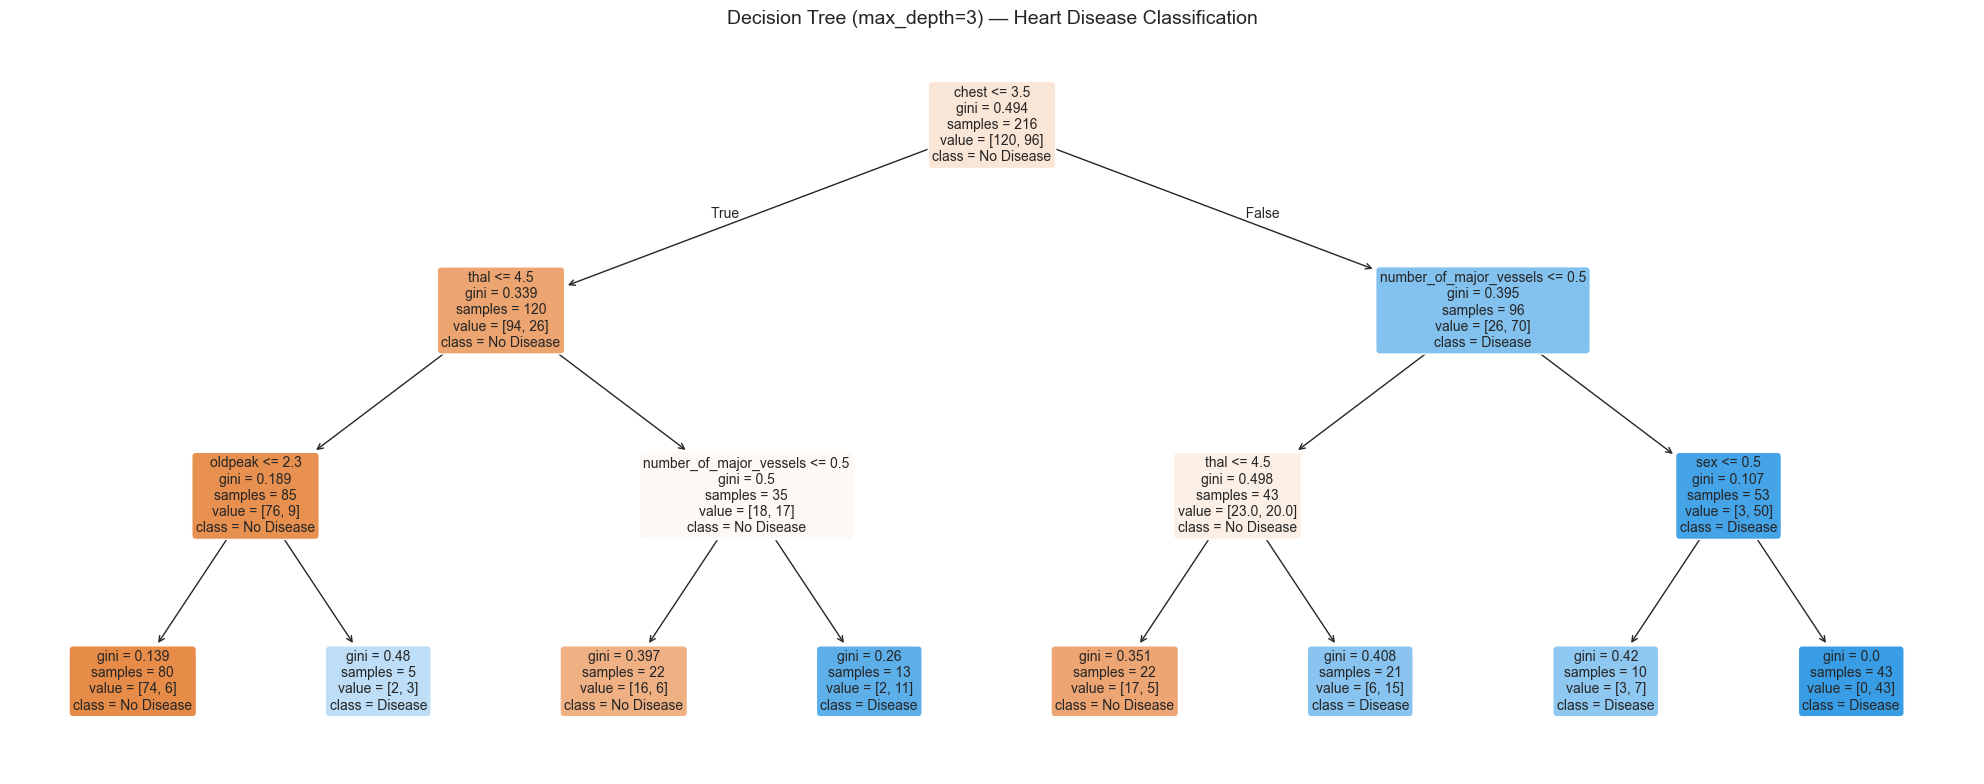

In [12]:
# Plot the actual decision tree — this is the key interpretability advantage
plt.figure(figsize=(20, 8))
plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True,
    proportion=False
)
plt.title('Decision Tree (max_depth=3) — Heart Disease Classification', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Text representation — useful for printing / reporting
print(export_text(dt_clf, feature_names=feature_names))

|--- chest <= 3.50
|   |--- thal <= 4.50
|   |   |--- oldpeak <= 2.30
|   |   |   |--- class: 0
|   |   |--- oldpeak >  2.30
|   |   |   |--- class: 1
|   |--- thal >  4.50
|   |   |--- number_of_major_vessels <= 0.50
|   |   |   |--- class: 0
|   |   |--- number_of_major_vessels >  0.50
|   |   |   |--- class: 1
|--- chest >  3.50
|   |--- number_of_major_vessels <= 0.50
|   |   |--- thal <= 4.50
|   |   |   |--- class: 0
|   |   |--- thal >  4.50
|   |   |   |--- class: 1
|   |--- number_of_major_vessels >  0.50
|   |   |--- sex <= 0.50
|   |   |   |--- class: 1
|   |   |--- sex >  0.50
|   |   |   |--- class: 1



In [14]:
feature_names

['age',
 'sex',
 'chest',
 'resting_blood_pressure',
 'serum_cholestoral',
 'fasting_blood_sugar',
 'resting_electrocardiographic_results',
 'maximum_heart_rate_achieved',
 'exercise_induced_angina',
 'oldpeak',
 'slope',
 'number_of_major_vessels',
 'thal']

**Reading the tree:**
* Each **node** shows: the split condition, the Gini impurity (0 = pure, 0.5 = maximally mixed for binary), the number of training samples, and the class breakdown.
* **Blue nodes** lean toward No Disease; **orange nodes** lean toward Disease (darker = purer).
* Each **leaf** (bottom node) gives the final prediction.

### 1.2 The Overfitting Problem — Depth vs Accuracy

In [15]:
train_accs, test_accs = [], []
depths = range(1, 20)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

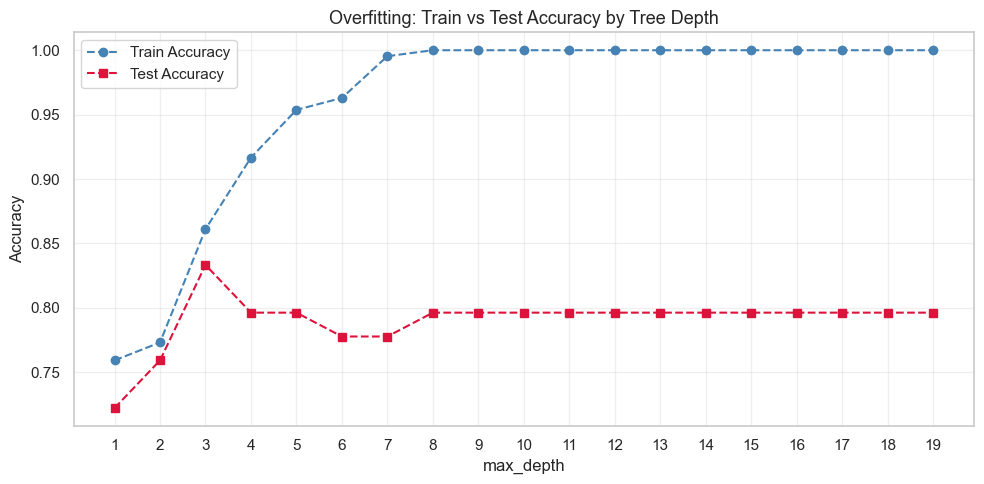

Best test accuracy at max_depth=3: 0.8333
Notice: train accuracy reaches 1.0 long before test accuracy peaks — that's overfitting.


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy',
         color='steelblue', linestyle='--', markerfacecolor='steelblue')
plt.plot(depths, test_accs, marker='s', label='Test Accuracy',
         color='crimson', linestyle='--', markerfacecolor='crimson')
plt.title('Overfitting: Train vs Test Accuracy by Tree Depth', fontsize=13)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(list(depths))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths.start + np.argmax(test_accs)
print(f"Best test accuracy at max_depth={best_depth}: {max(test_accs):.4f}")
print("Notice: train accuracy reaches 1.0 long before test accuracy peaks — that's overfitting.")

**Key insight:** A fully grown tree (no `max_depth` limit) achieves 100% training accuracy — it has memorised every training sample, including the noise. But test accuracy tells the real story. The gap between the two lines is the **overfitting gap**.

### 1.3 Confusion Matrix

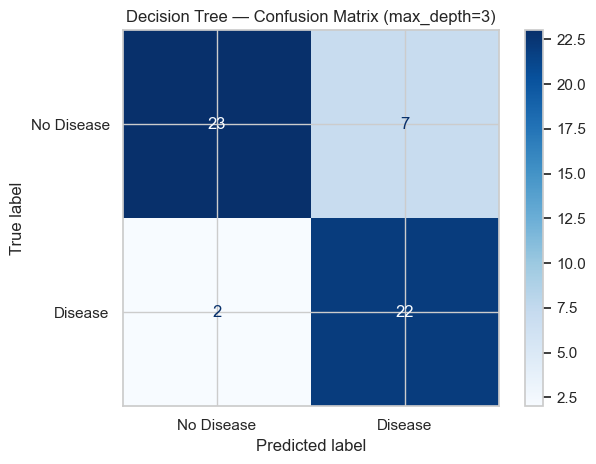

In [17]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix (max_depth=3)')
plt.tight_layout()
plt.show()

---
## 3. Decision Tree Regression (Medical Insurance Dataset)

Decision Trees also handle continuous targets. The tree splits data to minimise the **Mean Squared Error (MSE)** within each leaf, then predicts the **mean** of all training samples that fall into that leaf.

We will use the **Medical Insurance** dataset to predict patient charges. This is a useful regression case because the relationship between features and cost is non-linear (smokers face disproportionately high costs), which a tree handles naturally.

In [18]:
try:
    df_ins = pd.read_csv('data/insurance.csv')
    print("Loaded from CSV.")
except FileNotFoundError:
    from sklearn.datasets import make_regression
    rng = np.random.default_rng(42)
    n = 1338
    age = rng.integers(18, 65, n)
    bmi = rng.normal(30, 6, n).clip(15, 55)
    children = rng.integers(0, 5, n)
    smoker = rng.integers(0, 2, n)
    charges = (age * 250 + bmi * 330 + children * 400
               + smoker * 24000 + rng.normal(0, 2500, n)).clip(1000)
    df_ins = pd.DataFrame({'age': age, 'bmi': bmi, 'children': children,
                            'smoker': smoker, 'charges': charges})
    print("CSV not found — using synthetic data.")

# Encode categorical columns if present
if df_ins['smoker'].dtype == object:
    df_ins['smoker'] = df_ins['smoker'].map({'yes': 1, 'no': 0})
if 'sex' in df_ins.columns and df_ins['sex'].dtype == object:
    df_ins['sex'] = df_ins['sex'].map({'male': 0, 'female': 1})
if 'region' in df_ins.columns and df_ins['region'].dtype == object:
    df_ins = pd.get_dummies(df_ins, columns=['region'], drop_first=True)

print(f"Dataset shape: {df_ins.shape}")
df_ins.head()

CSV not found — using synthetic data.
Dataset shape: (1338, 5)


,age,bmi,children,smoker,charges
0,22,27.976049,0,1,37716.762065
1,54,29.147981,1,1,44947.573033
2,48,33.691541,4,1,48175.349366
3,38,19.615970,2,0,17466.630670
4,38,30.986344,1,1,42888.622516


In [19]:
X_reg = df_ins.drop('charges', axis=1)
y_reg = df_ins['charges']
reg_feature_names = X_reg.columns.tolist()

In [20]:
reg_feature_names

['age', 'bmi', 'children', 'smoker']

In [21]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [22]:
dt_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_reg.fit(X_train_r, y_train_r)
y_pred_dt_r = dt_reg.predict(X_test_r)

In [23]:
mae_dt  = mean_absolute_error(y_test_r, y_pred_dt_r)
rmse_dt = np.sqrt(mean_squared_error(y_test_r, y_pred_dt_r))
r2_dt   = r2_score(y_test_r, y_pred_dt_r)

In [24]:
print("--- Decision Tree Regression (max_depth=4) ---")
print(f"MAE  : ${mae_dt:,.0f}")
print(f"RMSE : ${rmse_dt:,.0f}")
print(f"R²   : {r2_dt:.4f}")

--- Decision Tree Regression (max_depth=4) ---
MAE  : $2,211
RMSE : $2,807
R²   : 0.9507


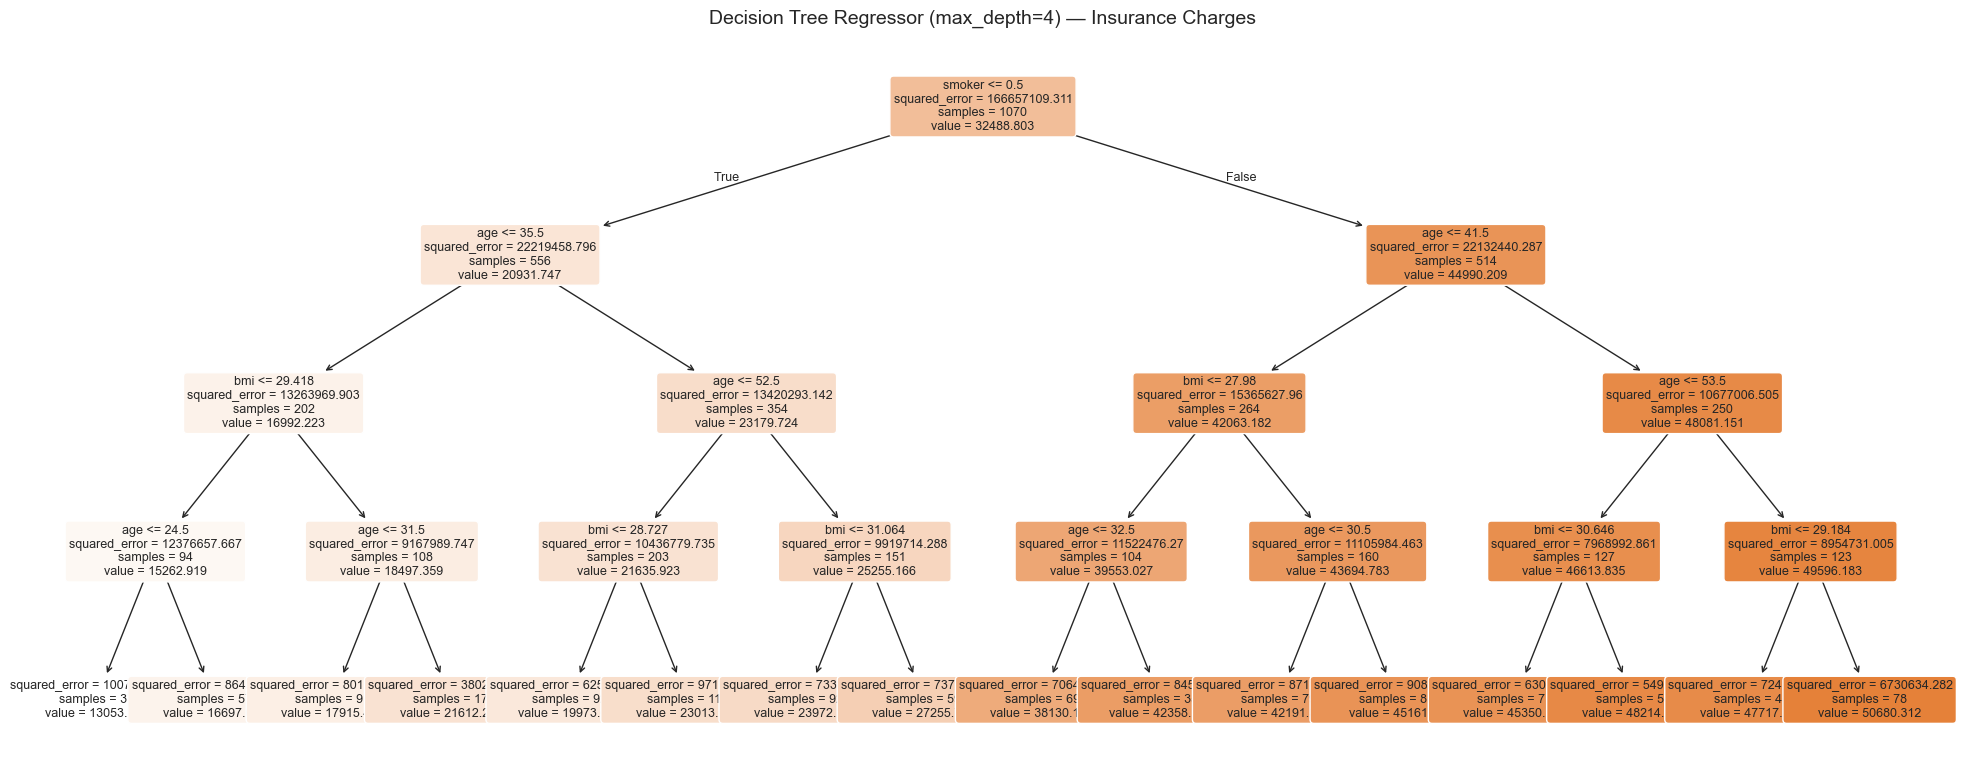

In [25]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_reg,
    feature_names=reg_feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True
)
plt.title('Decision Tree Regressor (max_depth=4) — Insurance Charges', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Cross-Validation — A More Honest Evaluation

A single train/test split can be lucky or unlucky depending on which samples ended up in the test set. **K-Fold Cross-Validation** is a better evaluation strategy:

1. Split data into $K$ equal folds.
2. Train on $K-1$ folds, evaluate on the remaining fold.
3. Repeat $K$ times (each fold gets to be the test set once).
4. Report the **mean and standard deviation** across all $K$ scores.

A low standard deviation means the model performs consistently — it's not getting lucky on one particular split.

In [26]:
models = {
    'Decision Tree (depth=3)':    DecisionTreeClassifier(max_depth=3, random_state=42),
    'Decision Tree (unlimited)':  DecisionTreeClassifier(random_state=42),
}

print("5-Fold Cross-Validation — Heart Disease Classification\n")
print(f"{'Model':<35} {'Mean Acc':>10} {'Std':>8}")
print('-' * 55)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<35} {scores.mean():.4f}    ± {scores.std():.4f}")

5-Fold Cross-Validation — Heart Disease Classification

Model                                 Mean Acc      Std
-------------------------------------------------------
Decision Tree (depth=3)             0.8037    ± 0.0532
Decision Tree (unlimited)           0.7222    ± 0.0915


C:\Users\arhan\AppData\Local\Temp\ipykernel_1844\690255569.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,


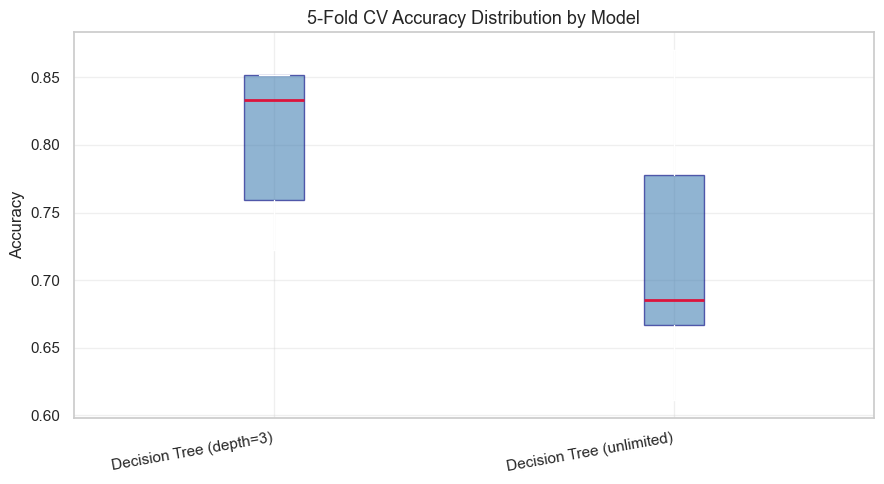

In [27]:
# Box plot of CV scores
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='steelblue', color='navy', alpha=0.6),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_title('5-Fold CV Accuracy Distribution by Model', fontsize=13)
ax.set_ylabel('Accuracy')
ax.set_xticklabels(cv_results.keys(), rotation=10, ha='right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key insight:** The unlimited Decision Tree gets high CV scores on some folds and poor scores on others (wide box = high variance). The Random Forest is consistently high with a much narrower spread — this stability is the hallmark of a well-generalising ensemble model.

---
## 6. Summary — Decision Trees

**Advantages:**
1. **Fully interpretable:** You can literally draw and explain the model. Ideal for regulated industries (healthcare, finance) where you must justify a prediction.
2. **No preprocessing required:** Handles mixed numeric/categorical data. No scaling, no one-hot encoding needed (in principle).
3. **Fast to train and predict.**
4. **Captures non-linear relationships** and feature interactions naturally.

**Disadvantages:**
1. **High variance / overfitting:** A fully grown tree memorises the training data. Depth must be controlled carefully.
2. **Instability:** Small changes in the training data can produce a completely different tree.
3. **Biased toward features with many unique values:** Features with more possible thresholds get more chances to be chosen as splits.
